## Can a computer learn if we're going to detect gravitational waves?
This episode of "time to get your hands dirty" is about something I studied carefully in the past: gravitational-wave selection effects. This is one the LIGO interferometers:

All experiments have selection effects. Some sources are easier to detect than others which distorts the population of sources we observe (this crucial in astronomy! Surveys are typically flux limited). 
In order to decided if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our selection effects (for instance: it would be wrong to say that all stars are close by just because we can't observe those that are very far!). In observational astronomy, this is known as [Malmquist bias](https://en.wikipedia.org/wiki/Malmquist_bias) and was first formulated in 1922.
 
**The goal here is to machine-learn the LIGO detectability: can we *predict* if a gravitational-wave source will be detected?**  

[This dataset](https://github.com/dgerosa/pdetclassifier/releases/download/v0.2/sample_2e7_design_precessing_higherordermodes_3detectors.h5) contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the [.h5 format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with `h5py`.

In particular, each source has the following features:
- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

The detectability is defined using the `snr` (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. Some (many?) of you will have studied this in the gravitational-wave class; [see here](https://arxiv.org/abs/1908.11170) for a nice write-up. All you need to know now is that we threshold the `snr` values and assume that LIGO will (not) see a source if `snr`>12 (`snr`<12). The resulting 0-1 labels are reported in the `det` attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't. 

Be creative! This is a challenge! Let's see who gets the  higher completeness and/or the smaller contamination (on a validation set, of course, careful with overfitting here).

*Tips*:
- You can downsample the data for debugging purposes
- You can also use only some of the features.
- Plot ROC curves
- **Important** Don't use `snr` as feature in your classifer (that's the answer...)


### Other ideas (optional)

- Using the same data, we could run a regressor on `snr` instead of a classifier on `det`. We can then threshold the predictions (instead of tresholding the data like we're doing now). Would this give a better performance?

- How about trying to reduce the dimensionality of the dataset with a PCA-type algorithm to ease the classification problem?


In [5]:
import numpy as np
import pylab as plt
import h5py
import sklearn.model_selection

In [6]:
file = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5')

In [7]:
print(file.keys())
N = len(file['det'])
print(f"Il numero di samples è: {N}")
#facciamo un downsampling per comodità. Normalmente sono 20 milioni, prendiamone 100.000
N_debug = int(1e5) 

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>
Il numero di samples è: 20000000


In [8]:
#Costruiamo un dizionario ridimensionato per il debug
data_debug = {} 
for key in file.keys():
    data_debug[key] = file[key][:N_debug]

#Creiamo i dati prendendo solo le feature che ci servono, ovvero escludendo 'det' e 'snr' che sono i target e rischierebbero di fare data leaking
feature_keys = [key for key in data_debug.keys() if key not in ['det', 'snr']]

X = np.column_stack([data_debug[key] for key in feature_keys]) #features
y = data_debug['det'] #target
snr = data_debug['snr']

In [9]:
#Splittiamo in train + test e poi usiamo lo Scaler separatamente (non insieme perché sennò il train sarebbe
#influenzato dal test), per rendere le features uniformi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#70% train e 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

Text(0, 0.5, 'z')

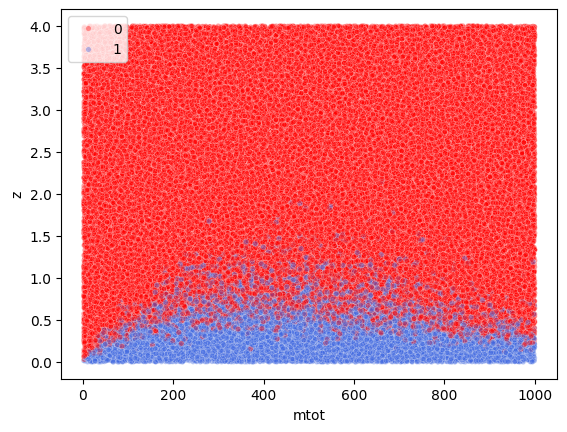

In [10]:
import seaborn as sns
sns.scatterplot(
    x=data_debug['mtot'], 
    y=data_debug['z'], 
    hue=data_debug['det'], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.4, 
    s=15)
plt.xlabel('mtot')
plt.ylabel('z')

Text(0, 0.5, 'q')

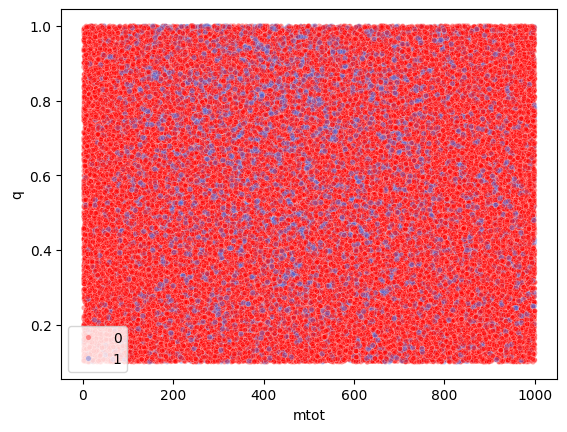

In [11]:
sns.scatterplot(
    x=data_debug['mtot'], 
    y=data_debug['q'], #mass ratio
    hue=data_debug['det'], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.4, 
    s=15)
plt.xlabel('mtot')
plt.ylabel('q')

Text(0, 0.5, 'iota')

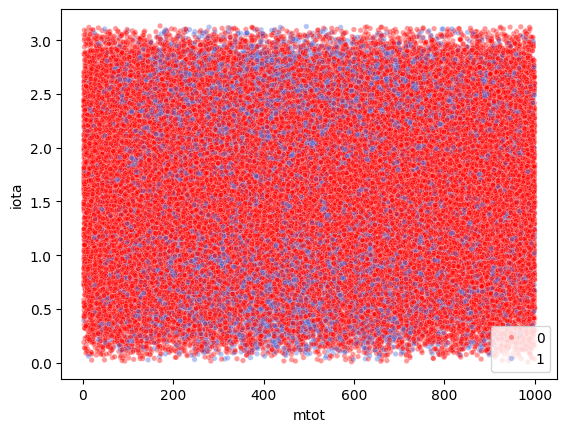

In [12]:
sns.scatterplot(
    x=data_debug['mtot'], 
    y=data_debug['iota'], #l'inclinazione del piano orbitale
    hue=data_debug['det'], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.4, 
    s=15)
plt.xlabel('mtot')
plt.ylabel('iota')

Text(0, 0.5, 'psi')

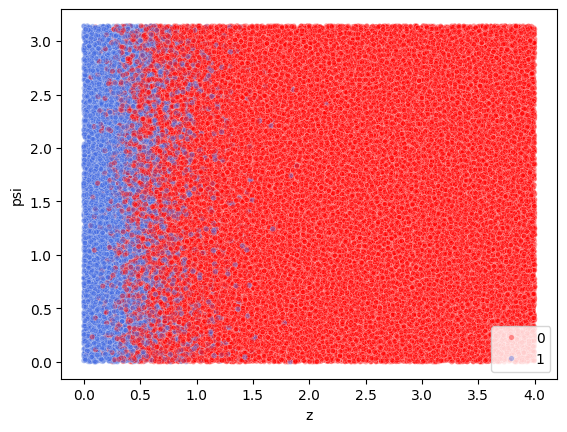

In [13]:
sns.scatterplot(
    x=data_debug['z'], 
    y=data_debug['psi'], #polarizzazione dell'onda
    hue=data_debug['det'], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.4, 
    s=15)
plt.xlabel('z')
plt.ylabel('psi')

Text(0, 0.5, 'iotafrom sklearn.tree import DecisionTreeClassifier')

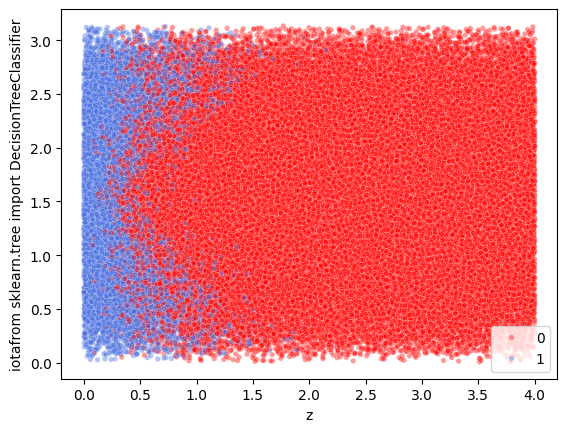

In [14]:
sns.scatterplot(
    x=data_debug['z'], 
    y=data_debug['iota'], #inclinazione dell'angolo orbitale
    hue=data_debug['det'], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.4, 
    s=15)
plt.xlabel('z')
plt.ylabel('iotafrom sklearn.tree import DecisionTreeClassifier')

Emerge in determinati grafici ad occhio degli effetti di non-linearità (soprattutto in quello mtot vs z). Dunque escluerei il Linear Regression.
Rimane da decidere tra l'SVM e il DecisionTree. Ho deciso di scegliere il secondo per sfruttare anche l'ensemble learning. Per l'optimal depth si va di cross-validation con GridSearch

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold
param = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]}
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
gs = GridSearchCV(estimator = DecisionTreeClassifier(random_state = 42), param_grid = param, cv = cv, n_jobs = -1, scoring = 'f1')
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
gs.fit(X_train, y_train)
optimal_depth = gs.best_params_['max_depth']

7


<ErrorbarContainer object of 3 artists>

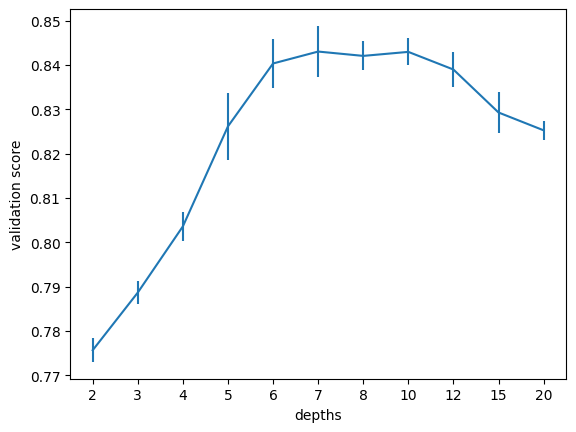

In [16]:
print(optimal_depth)
results = gs.cv_results_
depths = results['param_max_depth'].astype(str)
mean_scores = results['mean_test_score']
std_scores = results['std_test_score']
plt.ylabel('validation score')
plt.xlabel('depths')
plt.errorbar(depths, mean_scores, yerr = std_scores)
#print(results)

Facciamo un tentativo "plain", prendiamo l'optimal depth e lo fittiamo sul train con tutte le feature

In [17]:
dtc_plain = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy') #iniziamo con l'entropia
dtc_plain.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

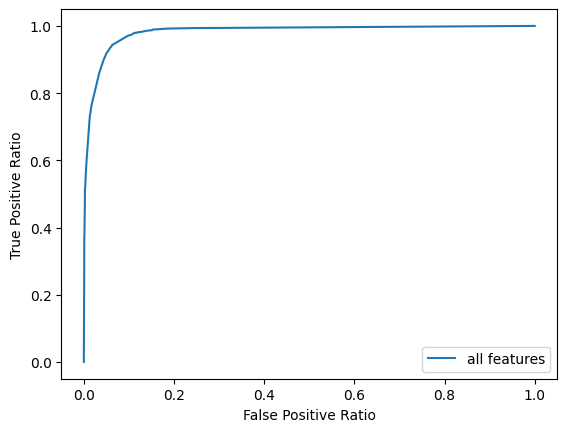

In [18]:
from sklearn.metrics import roc_curve
y_pred = dtc_plain.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label="all features")
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
plt.legend()

Mi sembra già una buona curva! a 0.1 FPR sono a 0.9 TPR. Proviamo a trainare con un numero progressivo di features

Text(0, 0.5, 'True Positive Ratio')

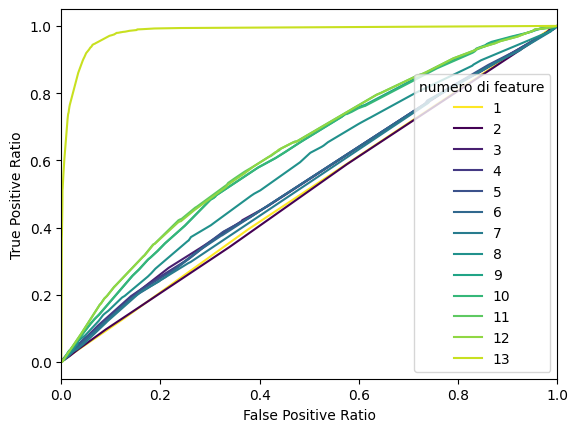

In [19]:

dtc_prog = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')
colors = plt.cm.viridis(np.linspace(0,1,13))
for i in range(13):
    dtc_prog.fit(X_train[:, 0:i+1], y_train)
    y_prob = dtc_prog.predict_proba(X_test[:, 0:i+1])[:, 1] #to obtain the probability estimates for the test set (per feature che crescono)
    fpr, tpr, thresh = roc_curve(y_test, y_prob) #false positive rate, true positive rate, threshold, rispetto alla y_test conosciuta e quella "computata"
    plt.plot(fpr, tpr, label=str(i+1), color = colors[i-1])
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')


In [20]:
print(feature_keys)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra', 'z']


Le curve sono piuttosto simili finché non si passa dalla 12esima (polarization angle) e si aggiunge la tredicesima (il redshift!). z migliora enormemente. Facciamolo con le ultime 5, ovvero mmtot, psi, q, ra, z

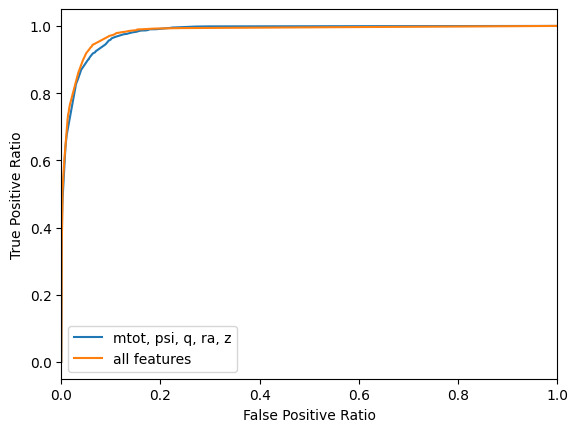

In [21]:
dtc_prog = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')
dtc_prog.fit(X_train[:, 8:13], y_train)
y_prob = dtc_prog.predict_proba(X_test[:, 8:13])[:, 1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = 'mtot, psi, q, ra, z')
plt.legend(title="numero di feature");
plt.xlim(0, 1.0)
plt.xlabel('False Positive Ratio')
plt.ylabel('True Positive Ratio')
y_pred = dtc_plain.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label="all features")
plt.legend()

Adesso che penso di aver estrapolato delle feature "pesanti" e che contengono gran parte dell'informazione, volevo un po' testare la dimensionality reduction (che è unsupervised, ma vediamo cosa ne esce fuori)

<Axes: >

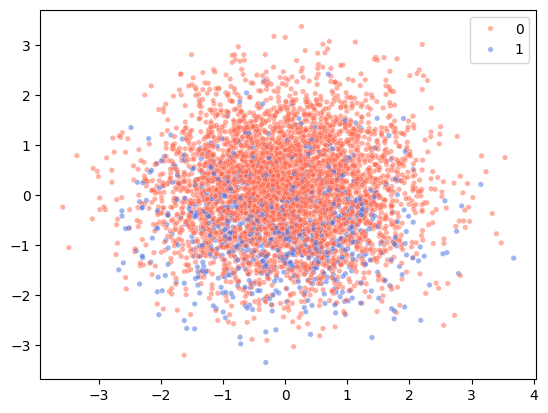

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_train_PCA = pca.fit_transform(X_train)
X_test_PCA = pca.transform(X_test)
sns.scatterplot(
    x=X_train_PCA[:5000, 0], 
    y=X_train_PCA[:5000, 1], 
    hue=y_train[:5000], 
    palette={0: 'tomato', 1: 'royalblue'}, 
    alpha=0.5, 
    s=15
)

Non è tanto incoraggiante, ma proviamo a usare il decision tree su questo spazio

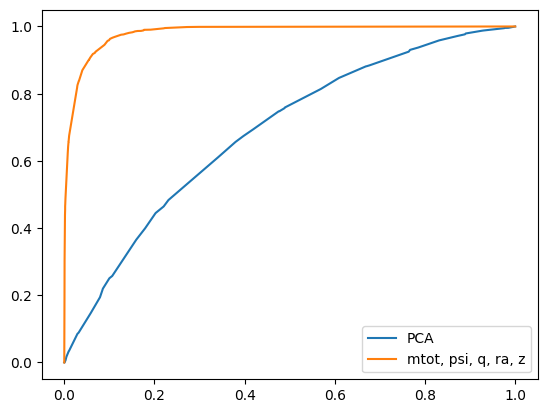

In [23]:
dtc_pca = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')
dtc_pca.fit(X_train_PCA, y_train)

y_prob_pca = dtc_pca.predict_proba(X_test_PCA)[:,1]
fpr_pca, tpr_pca, _ = roc_curve(y_test, y_prob_pca)
plt.plot(fpr_pca, tpr_pca, label ='PCA')

dtc_prog = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')
dtc_prog.fit(X_train[:, 8:13], y_train)
y_prob = dtc_prog.predict_proba(X_test[:, 8:13])[:, 1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = 'mtot, psi, q, ra, z')
plt.legend()

CVD, la curva ROC è piuttosto chiara sull'usare il PCA nello spazio delle 5 feature che abbiamo selezionato. Ma posso ipotizzare sia dovuto al fatto che c'è non-linearità. Provo con una tecnica non-lineare come IsoMap e vediamo se si ottiene una classificazione migliore o anche un modo comodo per visualizzare la distinzione su un plot 2D. Devo farlo con meno punti sennò mi esplode il portatile

In [24]:
from sklearn.manifold import Isomap
N_iso = 4000
features = ['mtot', 'psi', 'q', 'ra', 'z']
X_iso = np.column_stack([data_debug[key][:N_iso] for key in features])
y_iso = data_debug['det'][:N_iso]

X_train_iso, X_test_iso, y_train_iso, y_test_iso = train_test_split(
    X_iso, y_iso, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_iso = scaler.fit_transform(X_train_iso)
X_test_iso = scaler.transform(X_test_iso)

<Axes: >

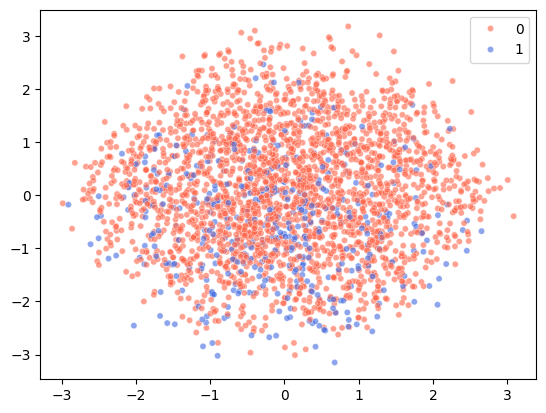

In [25]:
iso = Isomap(n_neighbors = 50, n_components=2, n_jobs=-1)
X_train_iso = iso.fit_transform(X_train_iso)
X_test_iso = iso.transform(X_test_iso)
sns.scatterplot(
    x=X_train_iso[:, 0], 
    y=X_train_iso[:, 1], 
    hue=y_train_iso, 
    palette={0: 'tomato', 1: 'royalblue'}, 
    alpha=0.6, 
    s=20
)

Mi sto accanendo un po' sulla questione dimensionality reduction ma voglio vedere se almeno un metodo riesce a separare i dati. Proviamo con tSNE

In [26]:
from sklearn.manifold import TSNE
N_iso = int(1e4)
features = ['mtot', 'psi', 'q', 'ra', 'z']
X_iso = np.column_stack([data_debug[key][:N_iso] for key in features])
y_iso = data_debug['det'][:N_iso]

X_train_iso, X_test_iso, y_train_iso, y_test_iso = train_test_split(
    X_iso, y_iso, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_iso = scaler.fit_transform(X_train_iso)
X_test_iso = scaler.transform(X_test_iso)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_train_unfolded = tsne.fit_transform(X_train_iso)

<Axes: >

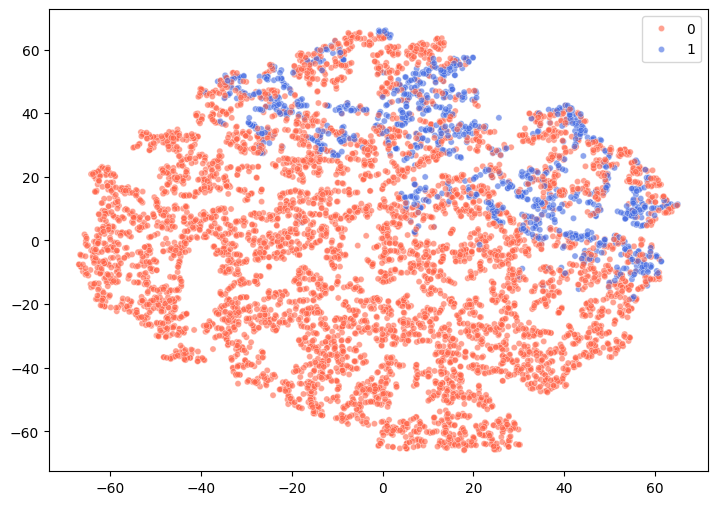

In [27]:
plt.figure(figsize=(8.5, 6))
sns.scatterplot(
    x=X_train_unfolded[:, 0], 
    y=X_train_unfolded[:, 1], 
    hue=y_train_iso, 
    palette={0: 'tomato', 1: 'royalblue'}, 
    alpha=0.6, 
    s=20
)

Direi che la modalità "locale" della sTNE ha funzionato meglio, almeno ora distinguo un'isola di misure rispetto agli 0. 

# Ensemble Learning

Facciamo un confronto tra le ROC curves di Bagging, Random forests, Boosting

In [28]:
n_forest = 10
#Albero decisionale "base"
dtc = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')

#DTC come prima con le 5 feature e senza ensemble learning
dtc_prog = DecisionTreeClassifier(max_depth = optimal_depth, criterion = 'entropy')
dtc_prog.fit(X_train[:, 8:13], y_train)
y_prob = dtc_prog.predict_proba(X_test[:, 8:13])[:, 1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)

In [29]:
#BAGGING
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(estimator=dtc,
    n_estimators=n_forest,      # numero di alberi 10 è il default
    max_samples=1.0,      
    max_features=1.0,      #ogni albero usa tutte e 5 le features
    bootstrap=True,        #bootstrapiamo i dati
    random_state=42,
    n_jobs=-1              
)
bagging.fit(X_train[:, 8:13], y_train)
y_prob_bag = bagging.predict_proba(X_test[:, 8:13])[:, 1]
fpr_bag, tpr_bag, thresh_bag = roc_curve(y_test, y_prob_bag)

In [30]:
#RANDOM FOREST: prendiamo dei subset di feature per lo splitting
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=n_forest,
                            max_depth=optimal_depth, random_state=42, n_jobs=-1, criterion ='entropy', )
rf.fit(X_train[:, 8:13], y_train)
y_prob_rf = rf.predict_proba(X_test[:, 8:13])[:, 1]
fpr_rf, tpr_rf, thresh_rf = roc_curve(y_test, y_prob_rf)

In [31]:
#BOOSTING: da quanto ho visto la libreria di sklearn è GradientBoostingClassifier https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
from sklearn.ensemble import GradientBoostingClassifier
boost = GradientBoostingClassifier(
    n_estimators=n_forest*10,      #di default sono a 100
    learning_rate=0.1,             #default, ma sarebbe uno shrink del contributo di ogni albero
    max_depth=3,                   #prendiamo come albero base un albero molto meno profondo, un classifier "weak"          
    random_state=42 #NB: niente parallel computing per noi, è un algoritmo sequenziale :(
)
boost.fit(X_train[:, 8:13], y_train)
y_prob_boost = boost.predict_proba(X_test[:, 8:13])[:, 1]
fpr_boost, tpr_boost, thresh_boost = roc_curve(y_test, y_prob_boost)

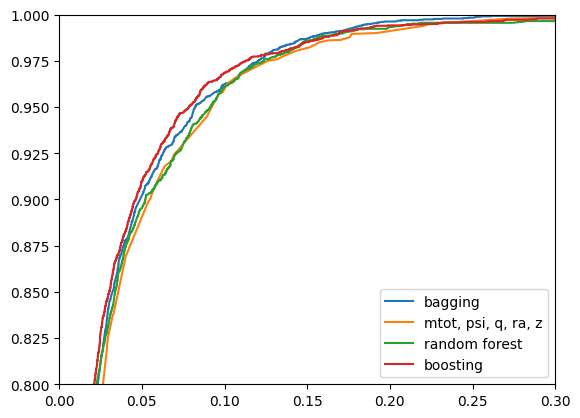

In [32]:
plt.plot(fpr_bag, tpr_bag, label  = 'bagging')
plt.plot(fpr, tpr, label = 'mtot, psi, q, ra, z')
plt.plot(fpr_rf, tpr_rf, label = 'random forest')
plt.plot(fpr_boost, tpr_boost, label = 'boosting')
plt.xlim(0.0, 0.3)
plt.ylim(0.8, 1)
plt.legend()

Mi aspettavo che il random forest fosse migliore del bagging, ma a quanto pare la ROC curve dice il contrario! ipotizzo sia perché abbiamo una feature che pesa molto, ovvero il redshift, dunque dato che nel random forest vengono fatti subset di circa sqrt(5) feature, l'assenza del redshift in molti di essi possa ridurre la prestazione.

Il boosting è il migliore tra gli ensemble sampler nel nostro caso.

Ma come è fatto l'outline del decision boundary col boosting? Ad esempio uno poco lineare come tra mtot e z

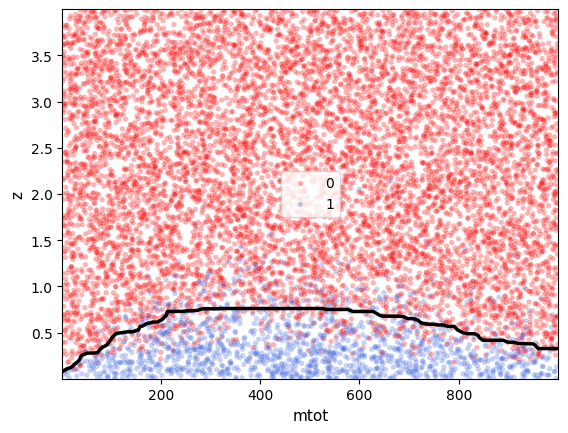

In [33]:
#reminder: come fare il plot di 2 dimensioni su 5
features_boundary = ['mtot', 'psi', 'q', 'ra', 'z']
X_raw = np.column_stack([data_debug[key] for key in features_boundary])
y_raw = data_debug['det']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)

local_scaler = StandardScaler()
local_scaler.fit(X_train_raw)

mtot_train_unscaled = X_train_raw[:, 0]
z_train_unscaled = X_train_raw[:, 4]

mtot_min, mtot_max = mtot_train_unscaled.min(), mtot_train_unscaled.max()
z_min, z_max = z_train_unscaled.min(), z_train_unscaled.max()


mtot_grid = np.linspace(mtot_min, mtot_max, 100)
z_grid = np.linspace(z_min, z_max, 100)
MTOT, Z = np.meshgrid(mtot_grid, z_grid)

#le feature che non sono contemplate nel grafico le freeziamo sullla loro mediana.
psi_median = np.median(X_train_raw[:, 1])
q_median = np.median(X_train_raw[:, 2])
ra_median = np.median(X_train_raw[:, 3])

grid_points = np.zeros((MTOT.size, 5))
grid_points[:, 0] = MTOT.ravel()   # ravel Return a contiguous flattened array.
grid_points[:, 1] = psi_median     
grid_points[:, 2] = q_median       
grid_points[:, 3] = ra_median      
grid_points[:, 4] = Z.ravel()      


grid_points_scaled = local_scaler.transform(grid_points)


probs = boost.predict_proba(grid_points_scaled)[:, 1]
PROB = probs.reshape(MTOT.shape)



subset = 10000

sns.scatterplot(
    x=mtot_train_unscaled[:subset], 
    y=z_train_unscaled[:subset], 
    hue=y_train_raw[:subset], 
    palette={0: 'red', 1: 'royalblue'}, 
    alpha=0.3, 
    s=15
)


contour = plt.contour(
    MTOT, Z, PROB, 
    levels=[0.5], #il contorno, ovvero dove la probabilità è al 50% 
    colors='black', 
    linewidths=2.5
)

plt.xlabel('mtot', fontsize=11)
plt.ylabel('z', fontsize=11)
plt.show()

# Regression su snr

Proviamo ad usare un Kernel Regression con una regolarizzazione Ridge

In [97]:
from sklearn.kernel_ridge import KernelRidge
krr = KernelRidge(kernel='rbf', alpha = 1, gamma = 0.1) #Regularization strength; must be a positive float. Sarebbe 1/2C

#E' un po' dispendioso e ho un po' timore a farlo su 100k dati, provo con 10k
N_krr = int(1e4)
features_krr = ['mtot', 'psi', 'q', 'ra', 'z']

X_krr = np.column_stack([data_debug[key][:N_krr] for key in features_krr])
snr_krr = data_debug['snr'][:N_krr]
y_krr = data_debug['det'][:N_krr]

X_train, X_test, snr_train, snr_test, y_train, y_test = train_test_split(
    X_krr, snr_krr, y_krr, test_size=0.3, random_state=42
)

scaler_k = StandardScaler()
X_train = scaler_k.fit_transform(X_train)
X_test = scaler_k.transform(X_test)

krr.fit(X_train, snr_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",'rbf'
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",0.1
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None


In [98]:
snr_pred = krr.predict(X_test)
fpr_krr, tpr_krr, _ = roc_curve(y_test, snr_pred)

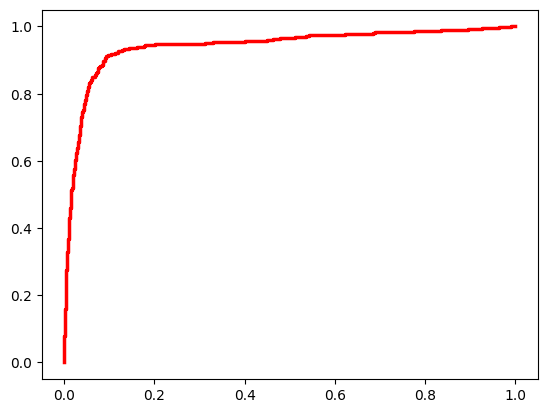

In [99]:
plt.plot(fpr_krr, tpr_krr, color='red', lw=2.5)

In [100]:
from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(snr_train, krr.predict(X_train))
mse_test = mean_squared_error(snr_test, snr_pred)

print(f"MSE sul train: {mse_train:.4f}")
print(f"MSE sul test:  {mse_test:.4f}")

MSE sul train: 35542.9890
MSE sul test:  10796.2663
